<!-- ---
title: "Modelagem hospitalização x não hospitalização"
format:
  html:
    theme: darkly
    toc: false
    code-fold: true  
    echo: false
    embed-resources: true
    page-layout: full
    include-in-header: 
      - text: |
          <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
jupyter: python3
--- -->


In [1]:
# import plotly.io as pio
# pio.renderers.default = "iframe_connected"   # ou "iframe"

## 1.Tratamento

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import numpy as np
from src import utils
from datetime import datetime
from sklearn import preprocessing
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [2]:
result = pd.read_parquet("fontes/df_tratado.parquet")

In [3]:
df = (result
     .assign(hospital = lambda _df: np.where(_df['HOSPITALIZ'] == 'Não hospitalizou', 0, 1))     
     .assign(vomito_nausea = lambda _df: np.where((_df['VOMITO'] + _df['NAUSEA']) >= 1, 1, 0))     
     .assign(diabetes_hiperten = lambda _df: np.where((_df['DIABETES'] + _df['HIPERTENSA']) >= 1, 1, 0))        
     .assign(alarm_abdom_plaq = lambda _df: np.where((_df['ALRM_PLAQ'] + _df['ALRM_ABDOM']) >= 1, 1, 0))     
     .assign(alarm_abdom_vom = lambda _df: np.where((_df['ALRM_VOM'] + _df['ALRM_ABDOM']) >= 1, 1, 0))     
     .assign(alarm_tds = lambda _df: np.where((_df[result[_df.columns.tolist()[76:85]].columns.tolist()].sum(axis=1)) >= 1, 1, 0))     
     .assign(grave_tds = lambda _df: np.where((_df[result[_df.columns.tolist()[86:101]].columns.tolist()].sum(axis=1)) >= 1, 1, 0))  
     .assign(grave_corr = lambda _df: np.where((_df['GRAV_PULSO'] + _df['GRAV_CONV'] + _df['GRAV_ENCH'] + _df['GRAV_INSUF'] + _df['GRAV_TAQUI'] + _df['GRAV_EXTRE'] + _df['GRAV_HIPOT'] + _df['GRAV_CONSC'] + _df['GRAV_ORGAO']) >= 1, 1, 0))     
)

In [4]:
sintomas = [
 'FEBRE',
 'MIALGIA',
 'CEFALEIA',
 'EXANTEMA',
 'VOMITO',
 'NAUSEA',
 'vomito_nausea',
 'DOR_COSTAS',
 'CONJUNTVIT',
 'ARTRITE',
 'ARTRALGIA',
 'PETEQUIA_N',
 'LEUCOPENIA',
 'LACO',
 'DOR_RETRO'
 ]

comorbidades = [
 'DIABETES',
 'HEMATOLOG',
 'HEPATOPAT',
 'RENAL',
 'HIPERTENSA',
 'ACIDO_PEPT',
 'AUTO_IMUNE',
 'diabetes_hiperten'
 ]

alarme = [
 'ALRM_HIPOT',
 'ALRM_PLAQ',
 'ALRM_VOM',
 'ALRM_SANG',
 'ALRM_HEMAT',
 'ALRM_ABDOM',
 'ALRM_LETAR',
 'ALRM_HEPAT',
 'ALRM_LIQ',
 'alarm_abdom_plaq',
 'alarm_abdom_vom',
 'alarm_tds'
 ]

grave = [
'GRAV_PULSO',
 'GRAV_CONV',
 'GRAV_ENCH',
 'GRAV_INSUF',
 'GRAV_TAQUI',
 'GRAV_EXTRE',
 'GRAV_HIPOT',
 'GRAV_HEMAT',
 'GRAV_MELEN',
 'GRAV_METRO',
 'GRAV_SANG',
 'GRAV_AST',
 'GRAV_MIOC',
 'GRAV_CONSC',
 'GRAV_ORGAO',
 'grave_tds'
 ]



In [5]:
df = (
    df
    .assign(**pd.get_dummies(df['Sexo']).astype(int))
)

In [6]:
def remover_itens(lista, itens):
    return [x for x in lista if x not in itens]


## 2. Modelagem

### 2.1 Cutoffs e colunas

In [7]:
#Opções de colunas para a modelagem

colunas_1 =  ['idade', 'M', 'F'] +  remover_itens(sintomas, ['VOMITO', 'NAUSEA']) + remover_itens(comorbidades, ['DIABETES', 'HIPERTENSA']) + remover_itens(alarme, ['ALRM_ABDOM', 'ALRM_PLAQ', 'ALRM_VOM', 'alarm_tds']) 

colunas_2 =  ['idade', 'M', 'F'] +  remover_itens(sintomas, ['VOMITO', 'NAUSEA']) + remover_itens(comorbidades, ['DIABETES', 'HIPERTENSA']) + remover_itens(alarme, ['ALRM_ABDOM', 'ALRM_PLAQ', 'ALRM_VOM', 'alarm_tds']) + ['grave_tds'] 


colunas_total = [colunas_2]


In [8]:
cutoff_rl = []
cutoff_xgb = []
cutoff_decision_tree = []

for i_colunas in colunas_total:
    X = df[i_colunas]
    y = df['hospital']

    cutoff_rl.append(utils.encontrar_cutoff(LogisticRegression, X, y, test_size=0.2, random_state=42))
    cutoff_xgb.append(utils.encontrar_cutoff(XGBClassifier, X, y, test_size=0.2, random_state=42))
    cutoff_decision_tree.append(utils.encontrar_cutoff(DecisionTreeClassifier, X, y, test_size=0.2, random_state=42, max_depth=3))


print(cutoff_rl)
print(cutoff_xgb)
print(cutoff_decision_tree)

C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[np.float64(0.05)]
[np.float32(0.05)]
[np.float64(0.09)]


### 2.2 Modelos com CV

In [ ]:
model_dict = {
    'random_forest': RandomForestClassifier(random_state=42),
    'decision_tree': DecisionTreeClassifier(random_state=42, max_depth=3),
    'logistic_regression': LogisticRegression(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'xgboost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

param_grids = {
    'logistic_regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'decision_tree': {
        'max_depth': [2, 3, 4, 5],
        'min_samples_split': [2, 5, 10]
    },
    'xgboost': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3]
    }
}


col_tabela = ['Modelo', 'Colunas', 'Cutoff', 'Acuracia', '1 - F1 Score', '1 - Precisão', '1 - Recall', 'AUC', 'Brier Score']
tabela_resultados = pd.DataFrame(columns=col_tabela)

for i_colunas, i_cutoff in zip(colunas_total, cutoff_rl):
            resul_temp = utils.train_and_evaluate_model_cv(df, i_colunas, target_column='hospital', model_type = model_dict.get('logistic_regression'), 
            cutoff = i_cutoff, param_grid=param_grids['logistic_regression'], search_method='random', n_iter=10 )
            tabela_resultados = pd.concat([tabela_resultados, resul_temp])

for i_colunas, i_cutoff in zip(colunas_total, cutoff_decision_tree):
            resul_temp = utils.train_and_evaluate_model_cv(df, i_colunas, target_column='hospital', random_state=41, model_type=model_dict.get('decision_tree'), cutoff = i_cutoff, param_grid=param_grids['decision_tree'], search_method='random', n_iter=10 )
            tabela_resultados = pd.concat([tabela_resultados, resul_temp])

for i_colunas, i_cutoff in zip(colunas_total, cutoff_xgb):
            resul_temp = utils.train_and_evaluate_model_cv(df, i_colunas, target_column='hospital', random_state=41, model_type=model_dict.get('xgboost'), cutoff = i_cutoff, param_grid=param_grids['xgboost'], search_method='random', n_iter=10 )
            tabela_resultados = pd.concat([tabela_resultados, resul_temp])

C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [21:18:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=StratifiedKFold(n_splits=4, random_state=41, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None...
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                  

In [13]:
pd.set_option('display.max_colwidth', None)
tabela_resultados.sort_values(by = ['AUC'], ascending = False, inplace = True)

In [15]:
tabela_resultados.to_excel('primeiros_resultados_cut_otim.xlsx')

In [14]:
tabela_resultados

,Modelo,Colunas,Cutoff,Acuracia,1 - F1 Score,1 - Precisão,1 - Recall,AUC,Brier Score,Hiperparâmetros
0,XGBClassifier,"[idade, M, F, FEBRE, MIALGIA, CEFALEIA, EXANTEMA, vomito_nausea, DOR_COSTAS, CONJUNTVIT, ARTRITE, ARTRALGIA, PETEQUIA_N, LEUCOPENIA, LACO, DOR_RETRO, HEMATOLOG, HEPATOPAT, RENAL, ACIDO_PEPT, AUTO_IMUNE, diabetes_hiperten, ALRM_HIPOT, ALRM_SANG, ALRM_HEMAT, ALRM_LETAR, ALRM_HEPAT, ALRM_LIQ, alarm_abdom_plaq, alarm_abdom_vom, grave_tds]",0.05,82.67,22.17,14.24,49.98,72.95,0.0390,"{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.3}"
0,LogisticRegression,"[idade, M, F, FEBRE, MIALGIA, CEFALEIA, EXANTEMA, vomito_nausea, DOR_COSTAS, CONJUNTVIT, ARTRITE, ARTRALGIA, PETEQUIA_N, LEUCOPENIA, LACO, DOR_RETRO, HEMATOLOG, HEPATOPAT, RENAL, ACIDO_PEPT, AUTO_IMUNE, diabetes_hiperten, ALRM_HIPOT, ALRM_SANG, ALRM_HEMAT, ALRM_LETAR, ALRM_HEPAT, ALRM_LIQ, alarm_abdom_plaq, alarm_abdom_vom, grave_tds]",0.05,79.69,20.26,12.57,52.24,71.82,0.0395,"{'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}"
0,DecisionTreeClassifier,"[idade, M, F, FEBRE, MIALGIA, CEFALEIA, EXANTEMA, vomito_nausea, DOR_COSTAS, CONJUNTVIT, ARTRITE, ARTRALGIA, PETEQUIA_N, LEUCOPENIA, LACO, DOR_RETRO, HEMATOLOG, HEPATOPAT, RENAL, ACIDO_PEPT, AUTO_IMUNE, diabetes_hiperten, ALRM_HIPOT, ALRM_SANG, ALRM_HEMAT, ALRM_LETAR, ALRM_HEPAT, ALRM_LIQ, alarm_abdom_plaq, alarm_abdom_vom, grave_tds]",0.09,94.47,33.21,41.19,27.83,66.92,0.0397,"{'min_samples_split': 2, 'max_depth': 5}"


### 2.3 Modelos finais

In [9]:
model_dict = {
    'random_forest': RandomForestClassifier(random_state=42),
    'xgboost': XGBClassifier(n_estimators=50, max_depth=5, learning_rate=0.3),
    'logistic_regression':LogisticRegression(solver='lbfgs', penalty='l2', C=0.1, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'decision_tree': DecisionTreeClassifier(min_samples_split=2, max_depth=5)
}

col_tabela = ['Modelo', 'Colunas', 'Cutoff', 'Acuracia', '1 - F1 Score', '1 - Precisão', '1 - Recall', 'AUC', 'Brier Score']
tabela_resultados = pd.DataFrame(columns=col_tabela)

for i_colunas, i_cutoff in zip(colunas_total, cutoff_rl):
            resul_temp = utils.train_and_evaluate_model(df, i_colunas, target_column='hospital', model_type = model_dict.get('logistic_regression'), 
            cutoff = i_cutoff)
            tabela_resultados = pd.concat([tabela_resultados, resul_temp])

for i_colunas, i_cutoff in zip(colunas_total, cutoff_decision_tree):
            resul_temp = utils.train_and_evaluate_model(df, i_colunas, target_column='hospital', random_state=41, model_type=model_dict.get('decision_tree'), cutoff = i_cutoff)
            tabela_resultados = pd.concat([tabela_resultados, resul_temp])

for i_colunas, i_cutoff in zip(colunas_total, cutoff_xgb):
            resul_temp = utils.train_and_evaluate_model(df, i_colunas, target_column='hospital', random_state=41, model_type=model_dict.get('xgboost'), cutoff = i_cutoff)
            tabela_resultados = pd.concat([tabela_resultados, resul_temp])

C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\danie\AppData\Local\Temp\ipykernel_25504\1934481356.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tabela_resultados = pd.concat([tabela_resultados, resul_temp])


In [10]:
tabela_resultados

,Modelo,Colunas,Cutoff,Acuracia,1 - F1 Score,1 - Precisão,1 - Recall,AUC,Brier Score,AUC IC95%
0,LogisticRegression,"[idade, M, F, FEBRE, MIALGIA, CEFALEIA, EXANTE...",0.05,79.80,20.15,12.52,51.61,71.79,0.0397,[71.15 - 72.44]
0,DecisionTreeClassifier,"[idade, M, F, FEBRE, MIALGIA, CEFALEIA, EXANTE...",0.09,94.44,33.32,40.87,28.13,66.97,0.0396,[66.4 - 67.52]
0,XGBClassifier,"[idade, M, F, FEBRE, MIALGIA, CEFALEIA, EXANTE...",0.05,82.64,22.21,14.26,50.17,72.88,0.0390,[72.26 - 73.47]


In [16]:
from sklearn.model_selection import train_test_split

X = df[colunas_1]
y = df['hospital']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

lr = LogisticRegression(solver='lbfgs', penalty='l2', C=0.1, random_state=42)
gnb = GaussianNB()
xgb = XGBClassifier(n_estimators=50, max_depth=5, learning_rate=0.3)
dt = DecisionTreeClassifier(min_samples_split=2, max_depth=5)

clf_list = [
    (lr, "Logistic"),
    (gnb, "Naive Bayes"),
    (xgb, "XGBClassifier"),
    (dt, "Decision tree"),
]

C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


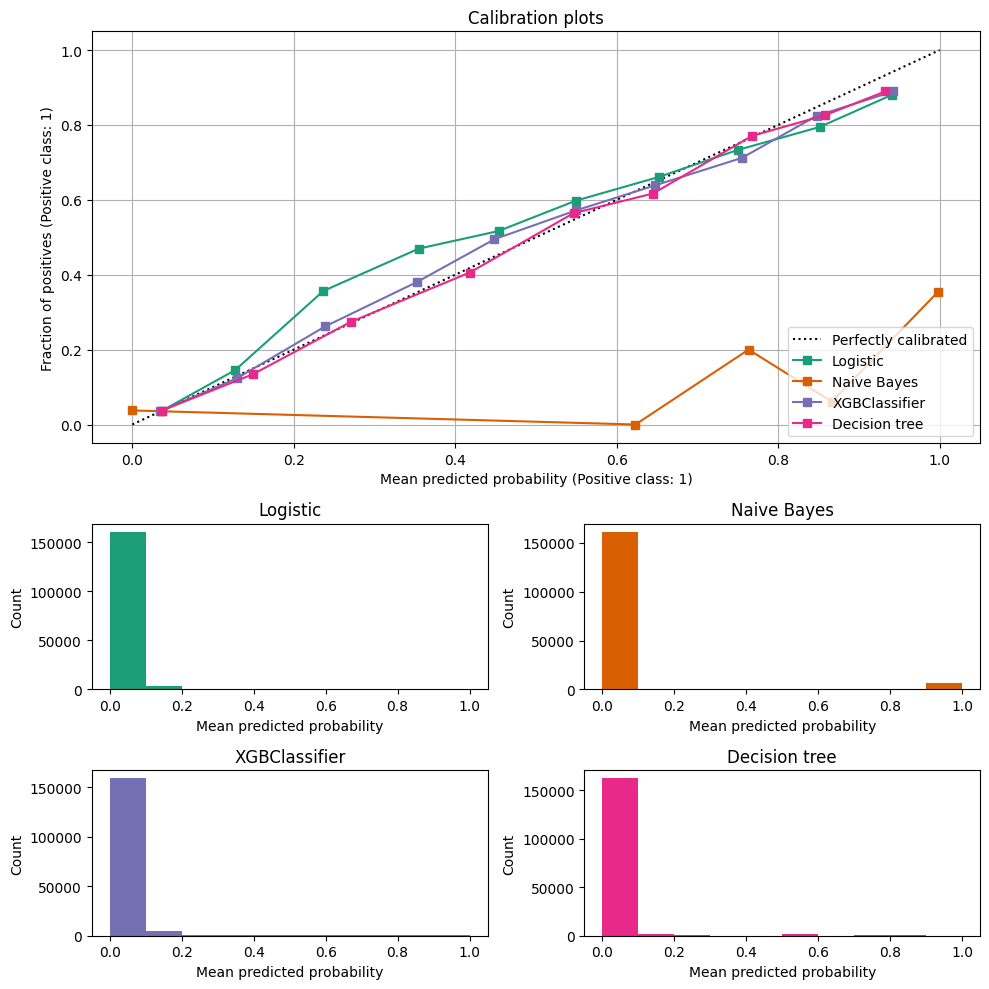

In [18]:
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(4, 2)
colors = plt.get_cmap("Dark2")

ax_calibration_curve = fig.add_subplot(gs[:2, :2])
calibration_displays = {}
for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train, y_train)
    display = CalibrationDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        n_bins=10,
        name=name,
        ax=ax_calibration_curve,
        color=colors(i),
    )
    calibration_displays[name] = display

ax_calibration_curve.grid()
ax_calibration_curve.set_title("Calibration plots")

# Add histogram
grid_positions = [(2, 0), (2, 1), (3, 0), (3, 1)]
for i, (_, name) in enumerate(clf_list):
    row, col = grid_positions[i]
    ax = fig.add_subplot(gs[row, col])

    ax.hist(
        calibration_displays[name].y_prob,
        range=(0, 1),
        bins=10,
        label=name,
        color=colors(i),
    )
    ax.set(title=name, xlabel="Mean predicted probability", ylabel="Count")

plt.tight_layout()
plt.show()

In [17]:
from collections import defaultdict

import pandas as pd

from sklearn.metrics import (
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

scores = defaultdict(list)
for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)
    y_pred = clf.predict(X_test)
    scores["Classifier"].append(name)

    for metric in [brier_score_loss, log_loss, roc_auc_score]:
        score_name = metric.__name__.replace("_", " ").replace("score", "").capitalize()
        scores[score_name].append(metric(y_test, y_prob[:, 1]))

    for metric in [precision_score, recall_score, f1_score]:
        score_name = metric.__name__.replace("_", " ").replace("score", "").capitalize()
        scores[score_name].append(metric(y_test, y_pred))

    score_df = pd.DataFrame(scores).set_index("Classifier")
    score_df.round(decimals=3)

score_df

C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [20:38:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Brier loss,Log loss,Roc auc,Precision,Recall,F1
Classifier,,,,,,
Logistic,0.039853,0.166710,0.717180,0.706105,0.179911,0.286758
Naive Bayes,0.060563,1.534779,0.706045,0.349226,0.269384,0.304152
XGBClassifier,0.039396,0.164992,0.726309,0.721784,0.187387,0.297530
Decision tree,0.040303,0.170173,0.656792,0.669663,0.215604,0.326188


###  Rascunhos

In [18]:
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.model_selection import cross_val_score
# import matplotlib.pyplot as plt

# depths = range(1, 21) 
# scores = []

# X = df[colunas]
# y = df['hospital']

# for depth in depths:
#     model = DecisionTreeClassifier(max_depth=depth, random_state=42)
#     score = cross_val_score(model, X, y, cv=4, scoring='roc_auc').mean()
#     scores.append(score)

# plt.plot(depths, scores, marker='o')
# plt.xlabel("Profundidade da Árvore")
# plt.ylabel("AUC Médio (CV)")
# plt.title("Escolha da Profundidade Ótima")
# plt.grid(True)
# plt.show()
